#Data Generation / Input


In [ ]:
#Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Make results reproducible
random.seed(42)
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
#Upload and read the CSV dataset

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
display(df)

Saving vehicle_locations.csv to vehicle_locations (1).csv
Dataset loaded successfully.


,Location,X,Y
0,Depot,50,50
1,A,10,20
2,B,20,80
3,C,70,90
4,D,90,30
5,E,60,10
6,F,30,40
7,G,80,70
8,H,15,60
9,I,40,85


In [ ]:
#Convert CSV data into location dictionary

locations = {}

for _, row in df.iterrows():
    locations[row["Location"]] = (
        float(row["X"]),
        float(row["Y"])
    )

print("Locations loaded from dataset:\n")

for name, coordinate in locations.items():
    print(f"{name}: {coordinate}")

print("\nTotal locations including depot:", len(locations))
print("Number of delivery locations:", len(locations) - 1)

Locations loaded from dataset:

Depot: (50.0, 50.0)
A: (10.0, 20.0)
B: (20.0, 80.0)
C: (70.0, 90.0)
D: (90.0, 30.0)
E: (60.0, 10.0)
F: (30.0, 40.0)
G: (80.0, 70.0)
H: (15.0, 60.0)
I: (40.0, 85.0)
J: (85.0, 15.0)
K: (25.0, 25.0)
L: (65.0, 55.0)
M: (75.0, 40.0)
N: (35.0, 70.0)

Total locations including depot: 15
Number of delivery locations: 14


In [ ]:
#Calculate pairwise distance matrix

location_names = list(locations.keys())
num_locations = len(location_names)

distance_matrix = np.zeros((num_locations, num_locations))

for i in range(num_locations):
    for j in range(num_locations):

        x1, y1 = locations[location_names[i]]
        x2, y2 = locations[location_names[j]]

        distance_matrix[i][j] = np.sqrt(
            (x2 - x1) ** 2 + (y2 - y1) ** 2
        )

distance_df = pd.DataFrame(
    distance_matrix,
    index=location_names,
    columns=location_names
)

print("Pairwise Distance Matrix")
display(distance_df.round(2))

Pairwise Distance Matrix


,Depot,A,B,C,D,E,F,G,H,I,J,K,L,M,N
Depot,0.00,50.00,42.43,44.72,44.72,41.23,22.36,36.06,36.40,36.40,49.50,35.36,15.81,26.93,25.00
A,50.00,0.00,60.83,92.20,80.62,50.99,28.28,86.02,40.31,71.59,75.17,15.81,65.19,68.01,55.90
B,42.43,60.83,0.00,50.99,86.02,80.62,41.23,60.83,20.62,20.62,91.92,55.23,51.48,68.01,18.03
C,44.72,92.20,50.99,0.00,63.25,80.62,64.03,22.36,62.65,30.41,76.49,79.06,35.36,50.25,40.31
D,44.72,80.62,86.02,63.25,0.00,36.06,60.83,41.23,80.78,74.33,15.81,65.19,35.36,18.03,68.01
E,41.23,50.99,80.62,80.62,36.06,0.00,42.43,63.25,67.27,77.62,25.50,38.08,45.28,33.54,65.00
F,22.36,28.28,41.23,64.03,60.83,42.43,0.00,58.31,25.00,46.10,60.42,15.81,38.08,45.00,30.41
G,36.06,86.02,60.83,22.36,41.23,63.25,58.31,0.00,65.76,42.72,55.23,71.06,21.21,30.41,45.00
H,36.40,40.31,20.62,62.65,80.78,67.27,25.00,65.76,0.00,35.36,83.22,36.40,50.25,63.25,22.36
I,36.40,71.59,20.62,30.41,74.33,77.62,46.10,42.72,35.36,0.00,83.22,61.85,39.05,57.01,15.81


#Route Representation and Population Initialization

In [ ]:
#Chromosome representation and initial population

delivery_locations = location_names[1:]

# Genetic Algorithm parameters
population_size = 50
number_of_generations = 200
crossover_rate = 0.90
mutation_rate = 0.10
elite_size = 2

# Create one random chromosome
def create_random_route():
    route = delivery_locations.copy()
    random.shuffle(route)
    return route


# Create the initial population
def create_initial_population():
    population = []

    for _ in range(population_size):
        population.append(create_random_route())

    return population


population = create_initial_population()

print("Population size:", len(population))

print("\nFirst 5 chromosomes:")

for i in range(5):
    print(f"Chromosome {i + 1}:", population[i])

Population size: 50

First 5 chromosomes:
Chromosome 1: ['I', 'M', 'H', 'G', 'N', 'L', 'F', 'C', 'J', 'D', 'E', 'A', 'B', 'K']
Chromosome 2: ['C', 'F', 'H', 'J', 'G', 'L', 'E', 'M', 'I', 'K', 'D', 'B', 'N', 'A']
Chromosome 3: ['H', 'I', 'D', 'L', 'K', 'N', 'B', 'M', 'F', 'G', 'C', 'A', 'E', 'J']
Chromosome 4: ['G', 'N', 'C', 'L', 'D', 'I', 'K', 'H', 'A', 'E', 'J', 'M', 'F', 'B']
Chromosome 5: ['E', 'I', 'G', 'C', 'H', 'M', 'A', 'B', 'D', 'L', 'F', 'J', 'K', 'N']


#Fitness Evaluation

In [ ]:
#Route distance and fitness functions

def calculate_route_distance(route):

    # Add depot at the beginning and end
    complete_route = ["Depot"] + route + ["Depot"]

    total_distance = 0

    for i in range(len(complete_route) - 1):

        current_location = complete_route[i]
        next_location = complete_route[i + 1]

        current_index = location_names.index(current_location)
        next_index = location_names.index(next_location)

        total_distance += distance_matrix[
            current_index
        ][
            next_index
        ]

    return total_distance


def calculate_fitness(route):

    distance = calculate_route_distance(route)

    # Higher fitness for smaller distance
    return 1 / distance


# Test using the first chromosome
test_route = population[0]

print("Test Route:")
print("Depot → " + " → ".join(test_route) + " → Depot")

print("\nTotal Distance:",
      round(calculate_route_distance(test_route), 2))

print("Fitness:",
      round(calculate_fitness(test_route), 6))

Test Route:
Depot → I → M → H → G → N → L → F → C → J → D → E → A → B → K → Depot

Total Distance: 733.82
Fitness: 0.001363


In [ ]:
#Evaluate the initial population

population_results = []

for route in population:

    distance = calculate_route_distance(route)
    fitness = calculate_fitness(route)

    population_results.append({
        "Route": "Depot → " + " → ".join(route) + " → Depot",
        "Distance": distance,
        "Fitness": fitness
    })


initial_results_df = pd.DataFrame(population_results)

initial_results_df = initial_results_df.sort_values(
    by="Distance"
).reset_index(drop=True)

print("Initial Population Results")
display(initial_results_df.head(10).round(4))


# Best route from the initial population
best_initial_distance = initial_results_df.iloc[0]["Distance"]

best_initial_route_text = initial_results_df.iloc[0]["Route"]

print("\nBest Initial Distance:",
      round(best_initial_distance, 2))

print("\nBest Initial Route:")
print(best_initial_route_text)

Initial Population Results


,Route,Distance,Fitness
0,Depot → G → N → C → L → D → I → K → H → A → E ...,637.0348,0.0016
1,Depot → A → M → K → J → E → D → G → F → I → L ...,638.9251,0.0016
2,Depot → D → M → K → I → N → H → B → J → L → F ...,654.3372,0.0015
3,Depot → I → B → L → H → C → M → J → E → F → G ...,657.0527,0.0015
4,Depot → N → I → F → M → D → J → K → H → A → G ...,658.8257,0.0015
5,Depot → A → N → F → B → I → K → G → J → D → E ...,665.2784,0.0015
6,Depot → F → D → M → J → C → N → K → L → G → B ...,673.9188,0.0015
7,Depot → J → A → B → N → H → I → M → C → G → E ...,674.4171,0.0015
8,Depot → H → G → J → M → D → C → A → F → E → I ...,676.7909,0.0015
9,Depot → E → A → C → G → B → L → D → I → H → F ...,679.2153,0.0015



Best Initial Distance: 637.03

Best Initial Route:
Depot → G → N → C → L → D → I → K → H → A → E → J → M → F → B → Depot


#Genetic Algorithm Operations

In [ ]:
#Tournament Selection

def tournament_selection(population, tournament_size=3):

    tournament = random.sample(
        population,
        tournament_size
    )

    winner = min(
        tournament,
        key=calculate_route_distance
    )

    return winner.copy()


# Test selection
selected_route = tournament_selection(population)

print("Selected Route:")
print("Depot → " + " → ".join(selected_route) + " → Depot")

print(
    "\nSelected Route Distance:",
    round(calculate_route_distance(selected_route), 2)
)

Selected Route:
Depot → I → B → L → H → C → M → J → E → F → G → N → K → A → D → Depot

Selected Route Distance: 657.05


In [ ]:
#Order Crossover (OX)

def order_crossover(parent1, parent2):

    length = len(parent1)

    # Select two crossover points
    start, end = sorted(
        random.sample(range(length), 2)
    )

    # Create empty child
    child = [None] * length

    # Copy section from parent 1
    child[start:end + 1] = parent1[start:end + 1]

    # Get remaining genes from parent 2
    remaining_genes = [
        gene
        for gene in parent2
        if gene not in child
    ]

    remaining_index = 0

    # Fill empty positions
    for i in range(length):

        if child[i] is None:
            child[i] = remaining_genes[remaining_index]
            remaining_index += 1

    return child


# Test crossover
parent1 = population[0]
parent2 = population[1]

child = order_crossover(parent1, parent2)

print("Parent 1:")
print(parent1)

print("\nParent 2:")
print(parent2)

print("\nChild:")
print(child)

print(
    "\nChild contains every location exactly once:",
    len(child) == len(set(child)) == len(delivery_locations)
)

Parent 1:
['I', 'M', 'H', 'G', 'N', 'L', 'F', 'C', 'J', 'D', 'E', 'A', 'B', 'K']

Parent 2:
['C', 'F', 'H', 'J', 'G', 'L', 'E', 'M', 'I', 'K', 'D', 'B', 'N', 'A']

Child:
['H', 'G', 'L', 'E', 'M', 'I', 'F', 'C', 'J', 'D', 'K', 'B', 'N', 'A']

Child contains every location exactly once: True


In [ ]:
#Swap Mutation

def swap_mutation(route):

    mutated_route = route.copy()

    # Select two positions
    index1, index2 = random.sample(
        range(len(mutated_route)),
        2
    )

    # Swap the two locations
    mutated_route[index1], mutated_route[index2] = (
        mutated_route[index2],
        mutated_route[index1]
    )

    return mutated_route


# Test mutation
original_route = population[0]

mutated_route = swap_mutation(original_route)

print("Original Route:")
print(original_route)

print("\nMutated Route:")
print(mutated_route)

Original Route:
['I', 'M', 'H', 'G', 'N', 'L', 'F', 'C', 'J', 'D', 'E', 'A', 'B', 'K']

Mutated Route:
['I', 'M', 'H', 'G', 'N', 'L', 'F', 'C', 'J', 'E', 'D', 'A', 'B', 'K']


In [ ]:
#Complete Genetic Algorithm

def genetic_algorithm():

    # Create initial population
    current_population = create_initial_population()

    best_route = None
    best_distance = float("inf")

    best_distance_history = []
    average_distance_history = []

    for generation in range(number_of_generations):

        # Sort population by route distance
        current_population = sorted(
            current_population,
            key=calculate_route_distance
        )

        # Current generation's best route
        current_best_route = current_population[0]

        current_best_distance = calculate_route_distance(
            current_best_route
        )

        # Update overall best solution
        if current_best_distance < best_distance:

            best_distance = current_best_distance

            best_route = current_best_route.copy()

        # Calculate population distances
        distances = [
            calculate_route_distance(route)
            for route in current_population
        ]

        # Save history
        best_distance_history.append(
            min(distances)
        )

        average_distance_history.append(
            np.mean(distances)
        )

        # Elitism
        new_population = [
            route.copy()
            for route in current_population[:elite_size]
        ]

        # Generate remaining population
        while len(new_population) < population_size:

            # Selection
            parent1 = tournament_selection(
                current_population
            )

            parent2 = tournament_selection(
                current_population
            )

            # Crossover
            if random.random() < crossover_rate:

                child1 = order_crossover(
                    parent1,
                    parent2
                )

                child2 = order_crossover(
                    parent2,
                    parent1
                )

            else:

                child1 = parent1.copy()
                child2 = parent2.copy()

            # Mutation
            if random.random() < mutation_rate:
                child1 = swap_mutation(child1)

            if random.random() < mutation_rate:
                child2 = swap_mutation(child2)

            # Add children
            new_population.append(child1)

            if len(new_population) < population_size:
                new_population.append(child2)

        # Move to next generation
        current_population = new_population

    return (
        best_route,
        best_distance,
        best_distance_history,
        average_distance_history
    )


print("Genetic Algorithm function created successfully.")

Genetic Algorithm function created successfully.


In [ ]:
#Run the Genetic Algorithm

(
    best_route,
    optimized_distance,
    best_distance_history,
    average_distance_history
) = genetic_algorithm()


print("Genetic Algorithm completed successfully!")

print("\nOptimized Route:")

print(
    "Depot → "
    + " → ".join(best_route)
    + " → Depot"
)

print(
    "\nOptimized Distance:",
    round(optimized_distance, 2)
)

print(
    "Number of Generations:",
    number_of_generations
)

Genetic Algorithm completed successfully!

Optimized Route:
Depot → I → C → G → L → M → D → J → E → K → A → F → H → B → N → Depot

Optimized Distance: 358.57
Number of Generations: 200


#Result Analysis

In [ ]:
#Compare initial and optimized solutions

initial_distance = best_initial_distance

distance_reduction = (
    initial_distance - optimized_distance
)

improvement_percentage = (
    distance_reduction / initial_distance
) * 100


print("=" * 55)
print("ROUTE COMPARISON")
print("=" * 55)

print("\nInitial Best Route:")
print(best_initial_route_text)

print(
    "\nInitial Distance:",
    round(initial_distance, 2)
)

print("\nOptimized Route:")
print(
    "Depot → "
    + " → ".join(best_route)
    + " → Depot"
)

print(
    "\nOptimized Distance:",
    round(optimized_distance, 2)
)

print(
    "\nDistance Reduced:",
    round(distance_reduction, 2)
)

print(
    "Improvement Percentage:",
    round(improvement_percentage, 2),
    "%"
)

ROUTE COMPARISON

Initial Best Route:
Depot → G → N → C → L → D → I → K → H → A → E → J → M → F → B → Depot

Initial Distance: 637.03

Optimized Route:
Depot → I → C → G → L → M → D → J → E → K → A → F → H → B → N → Depot

Optimized Distance: 358.57

Distance Reduced: 278.47
Improvement Percentage: 43.71 %


In [ ]:
#Create final results table

results = pd.DataFrame({

    "Metric": [
        "Initial Route Distance",
        "Optimized Route Distance",
        "Distance Reduction",
        "Improvement Percentage",
        "Number of Delivery Locations",
        "Population Size",
        "Number of Generations",
        "Crossover Rate",
        "Mutation Rate",
        "Elite Size"
    ],

    "Value": [
        round(initial_distance, 2),
        round(optimized_distance, 2),
        round(distance_reduction, 2),
        round(improvement_percentage, 2),
        len(delivery_locations),
        population_size,
        number_of_generations,
        crossover_rate,
        mutation_rate,
        elite_size
    ]
})


print("Final Project Results")

display(results)

Final Project Results


,Metric,Value
0,Initial Route Distance,637.03
1,Optimized Route Distance,358.57
2,Distance Reduction,278.47
3,Improvement Percentage,43.71
4,Number of Delivery Locations,14.00
5,Population Size,50.00
6,Number of Generations,200.00
7,Crossover Rate,0.90
8,Mutation Rate,0.10
9,Elite Size,2.00


#Visualization

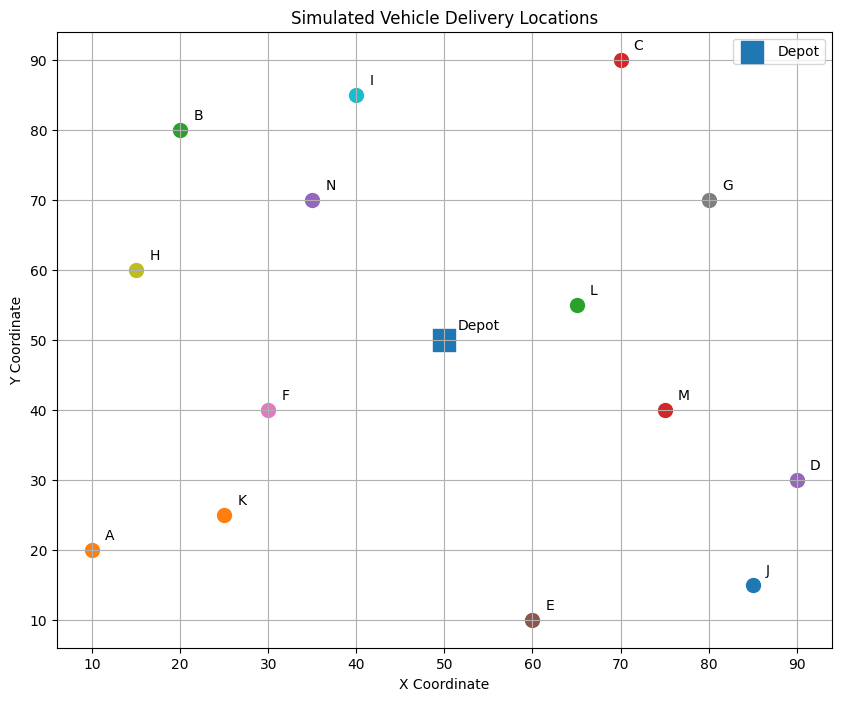

In [ ]:
#Visualize all delivery locations

plt.figure(figsize=(10, 8))

for name, (x, y) in locations.items():

    if name == "Depot":

        plt.scatter(
            x,
            y,
            s=250,
            marker="s",
            label="Depot"
        )

    else:

        plt.scatter(
            x,
            y,
            s=100
        )

    plt.text(
        x + 1.5,
        y + 1.5,
        name,
        fontsize=10
    )


plt.title(
    "Simulated Vehicle Delivery Locations"
)

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.grid(True)

plt.legend()

plt.show()

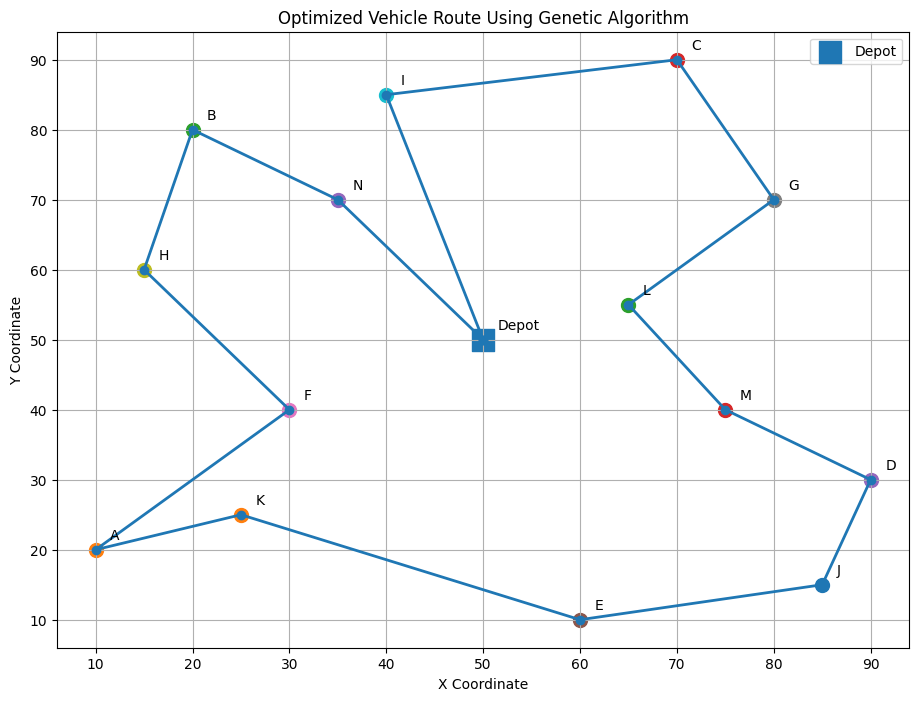

Optimized Route:
Depot → I → C → G → L → M → D → J → E → K → A → F → H → B → N → Depot

Optimized Total Distance: 358.57


In [ ]:
#Visualize optimized vehicle route

complete_best_route = (
    ["Depot"]
    + best_route
    + ["Depot"]
)


x_coordinates = [
    locations[location][0]
    for location in complete_best_route
]

y_coordinates = [
    locations[location][1]
    for location in complete_best_route
]


plt.figure(figsize=(11, 8))


# Draw the route
plt.plot(
    x_coordinates,
    y_coordinates,
    marker="o",
    linewidth=2
)


# Draw and label locations
for name, (x, y) in locations.items():

    if name == "Depot":

        plt.scatter(
            x,
            y,
            s=250,
            marker="s",
            label="Depot"
        )

    else:

        plt.scatter(
            x,
            y,
            s=100
        )

    plt.text(
        x + 1.5,
        y + 1.5,
        name,
        fontsize=10
    )


plt.title(
    "Optimized Vehicle Route Using Genetic Algorithm"
)

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.grid(True)

plt.legend()

plt.show()


print("Optimized Route:")
print(
    " → ".join(complete_best_route)
)

print(
    "\nOptimized Total Distance:",
    round(optimized_distance, 2)
)

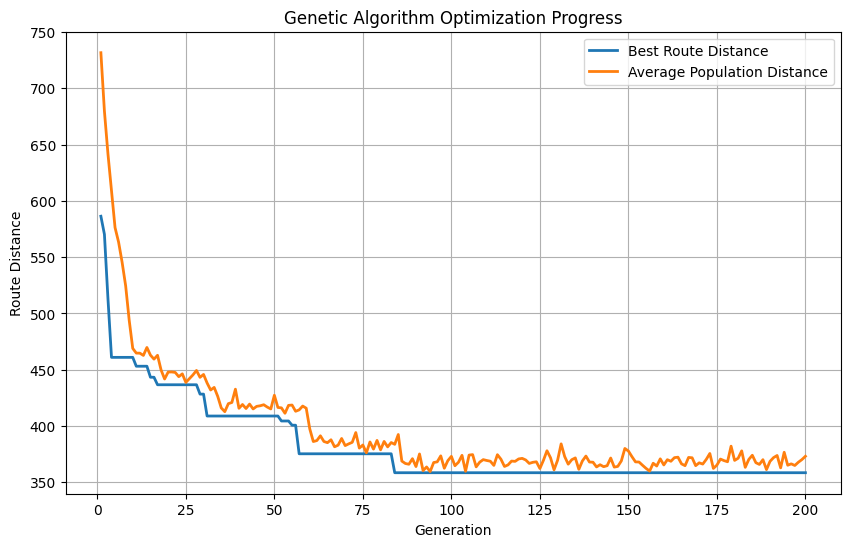

In [ ]:
#Plot Genetic Algorithm optimization progress

generation_numbers = range(
    1,
    number_of_generations + 1
)


plt.figure(figsize=(10, 6))


plt.plot(
    generation_numbers,
    best_distance_history,
    label="Best Route Distance",
    linewidth=2
)


plt.plot(
    generation_numbers,
    average_distance_history,
    label="Average Population Distance",
    linewidth=2
)


plt.title(
    "Genetic Algorithm Optimization Progress"
)

plt.xlabel("Generation")

plt.ylabel("Route Distance")

plt.grid(True)

plt.legend()

plt.show()

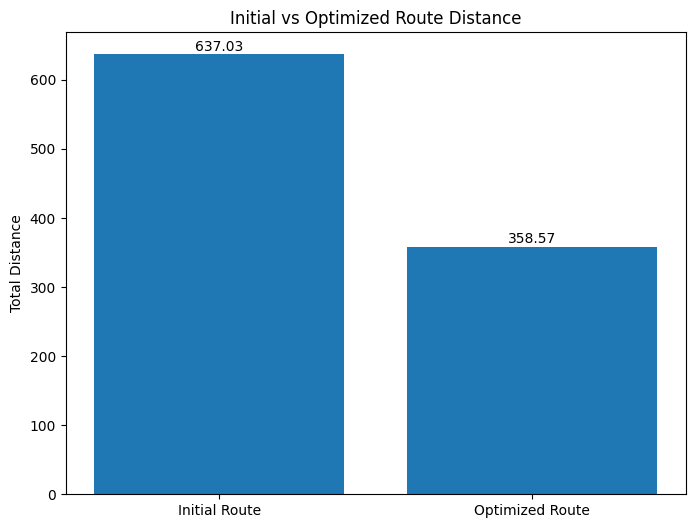

In [ ]:
#Compare initial and optimized distance

labels = [
    "Initial Route",
    "Optimized Route"
]

distances = [
    initial_distance,
    optimized_distance
]


plt.figure(figsize=(8, 6))


bars = plt.bar(
    labels,
    distances
)


plt.title(
    "Initial vs Optimized Route Distance"
)

plt.ylabel("Total Distance")


# Display values above bars
for bar, value in zip(bars, distances):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        f"{value:.2f}",
        ha="center"
    )


plt.show()

In [ ]:
#Final project summary

print("=" * 65)
print("VEHICLE ROUTE OPTIMIZATION USING GENETIC ALGORITHM")
print("=" * 65)


print("\nDATASET")
print("-" * 65)

print(
    "Number of delivery locations:",
    len(delivery_locations)
)

print("Depot included: Yes")

print(
    "Dataset type: Simulated coordinate-based CSV dataset"
)


print("\nGENETIC ALGORITHM")
print("-" * 65)

print(
    "Population size:",
    population_size
)

print(
    "Number of generations:",
    number_of_generations
)

print(
    "Crossover rate:",
    crossover_rate
)

print(
    "Mutation rate:",
    mutation_rate
)

print(
    "Elite size:",
    elite_size
)

print(
    "Selection method: Tournament Selection"
)

print(
    "Crossover method: Order Crossover (OX)"
)

print(
    "Mutation method: Swap Mutation"
)

print(
    "Elitism: Yes"
)


print("\nRESULTS")
print("-" * 65)

print(
    "Initial distance:",
    round(initial_distance, 2)
)

print(
    "Optimized distance:",
    round(optimized_distance, 2)
)

print(
    "Distance reduction:",
    round(distance_reduction, 2)
)

print(
    "Improvement:",
    round(improvement_percentage, 2),
    "%"
)


print("\nOPTIMIZED ROUTE")
print("-" * 65)

print(
    " → ".join(complete_best_route)
)


print("\nPROJECT STATUS")
print("-" * 65)

print(
    "Vehicle route optimization completed successfully."
)

VEHICLE ROUTE OPTIMIZATION USING GENETIC ALGORITHM

DATASET
-----------------------------------------------------------------
Number of delivery locations: 14
Depot included: Yes
Dataset type: Simulated coordinate-based CSV dataset

GENETIC ALGORITHM
-----------------------------------------------------------------
Population size: 50
Number of generations: 200
Crossover rate: 0.9
Mutation rate: 0.1
Elite size: 2
Selection method: Tournament Selection
Crossover method: Order Crossover (OX)
Mutation method: Swap Mutation
Elitism: Yes

RESULTS
-----------------------------------------------------------------
Initial distance: 637.03
Optimized distance: 358.57
Distance reduction: 278.47
Improvement: 43.71 %

OPTIMIZED ROUTE
-----------------------------------------------------------------
Depot → I → C → G → L → M → D → J → E → K → A → F → H → B → N → Depot

PROJECT STATUS
-----------------------------------------------------------------
Vehicle route optimization completed successfully.
